In [1]:
from matplotlib import pyplot as plt
import numpy as np

import wandb

import pandas as pd

In [2]:
api = wandb.Api()

In [3]:
PROJECT = "p16i/xaikd-s52-revised-distillation"
EXPERIMENT_GROUP= "student-cifar-resnet18-sweep-lambda-layer"

In [4]:
def read_data_per_policy(
    teacher, student,
    dataset,
    policy_alias,

    verbose=False,
    return_raw = False,
    training_size=1.0,
    experiment_group=EXPERIMENT_GROUP,
    return_only_best=True
):
    
    if policy_alias in ["kd-only", "student-only"]:
        experiment_group = "student-cifar-resnet18-with-valset"
        
    if policy_alias == "kd-only":
        lambda_task = 0
        lambda_kd = 1
        policy = "nothing"
    elif policy_alias == "student-only":
        lambda_task = 1
        lambda_kd = 0
        policy = "nothing"
    else:
        lambda_task = 0
        lambda_kd = 1
        policy = policy_alias
            
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": experiment_group},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.lambda-task": lambda_task},
            {"config.lambda-kd": lambda_kd},
            {"config.training_size": training_size},
            {"config.policy": policy},
        ]}
    )
    
    if verbose:
        print(f"{policy_alias} we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "student_test_auroc"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        rows.append(
            dict(
                policy_alias=policy_alias,
                train_auroc=run.summary["train_auroc"],
                
                val_auroc=run.summary["best_val_auroc"], 
                test_auroc=run.summary["student_test_auroc"],
                teacher_auroc=run.summary["teacher_auroc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    assert df.shape[0] > 0
    
    df = df.groupby(by="lambda_layer").agg(
        {
            
            "policy_alias": ["first"],
            "lambda_task": ["first"],
            "lambda_kd": ["first"],
            "lambda_layer": ["first"],
            "teacher_auroc": ["mean", "max", "min"],
            "train_auroc": ["mean", "sem", "count"],
            "val_auroc": ["mean", "sem", "count"],
            "test_auroc": ["mean", "sem", "count"],

        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_auroc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
        
    if return_only_best:
        df = df[df["val_auroc"]["mean"].max() == df["val_auroc"]["mean"]]
        
    return df

read_data_per_policy(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    policy_alias="basis-bn:prcaposdef",
    training_size=0.01,
    verbose=True,
    return_only_best=False
)

basis-bn:prcaposdef we have 21 runs
df.shape: (7, 17)


lambda_layer         policy_alias lambda_task lambda_kd lambda_layer  \
                              first       first     first        first   
0        0.001  basis-bn:prcaposdef           0         1        0.001   
1        0.010  basis-bn:prcaposdef           0         1        0.010   
2        0.100  basis-bn:prcaposdef           0         1        0.100   
3        1.000  basis-bn:prcaposdef           0         1        1.000   
4       10.000  basis-bn:prcaposdef           0         1       10.000   
5      100.000  basis-bn:prcaposdef           0         1      100.000   
6     1000.000  basis-bn:prcaposdef           0         1     1000.000   

  teacher_auroc         train_auroc                 val_auroc                  \
           mean max min        mean       sem count      mean       sem count   
0           1.0   1   1    0.999145  0.000405     3  0.674030  0.020088     3   
1           1.0   1   1    0.999881  0.000077     3  0.701424  0.008400     3   
2           1.0   1   1    0.999937  0.000063     3  0.710882  0.012880     3   
3           1.0   1   1    1.000000  0.000000     3  0.733792  0.014940     3   
4           1.0   1   1    0.964822  0.023552     3  0.731908  0.066106     3   
5           1.0   1   1    0.617573  0.029581     3  0.713487  0.044374     3   
6           1.0   1   1    0.547768  0.016810     3  0.702489  0.042501     3   

  test_auroc                  
        mean       sem count  
0   0.654920  0.026456     3  
1   0.698018  0.000423     3  
2   0.679024  0.016018     3  
3   0.723154  0.005376     3  
4   0.723697  0.060703     3  
5   0.722344  0.033213     3  
6   0.703677  0.036593     3

In [9]:
read_data_per_policy(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    policy_alias="basis-bn:prcaposdef",
    training_size=1.0,
    verbose=True,
    return_only_best=False
)

basis-bn:prcaposdef we have 21 runs
df.shape: (7, 17)


lambda_layer         policy_alias lambda_task lambda_kd lambda_layer  \
                              first       first     first        first   
0        0.001  basis-bn:prcaposdef           0         1        0.001   
1        0.010  basis-bn:prcaposdef           0         1        0.010   
2        0.100  basis-bn:prcaposdef           0         1        0.100   
3        1.000  basis-bn:prcaposdef           0         1        1.000   
4       10.000  basis-bn:prcaposdef           0         1       10.000   
5      100.000  basis-bn:prcaposdef           0         1      100.000   
6     1000.000  basis-bn:prcaposdef           0         1     1000.000   

  teacher_auroc         train_auroc                 val_auroc                  \
           mean max min        mean       sem count      mean       sem count   
0           1.0   1   1    0.999566  0.000293     3  0.965275  0.005873     3   
1           1.0   1   1    0.999821  0.000086     3  0.967169  0.004865     3   
2           1.0   1   1    0.999564  0.000170     3  0.981301  0.004642     3   
3           1.0   1   1    0.994498  0.000654     3  0.983510  0.002791     3   
4           1.0   1   1    0.981443  0.000724     3  0.982923  0.002381     3   
5           1.0   1   1    0.979772  0.000979     3  0.984091  0.001581     3   
6           1.0   1   1    0.980761  0.000363     3  0.982983  0.002086     3   

  test_auroc                  
        mean       sem count  
0   0.970861  0.000686     3  
1   0.971713  0.000969     3  
2   0.982995  0.001535     3  
3   0.981000  0.002873     3  
4   0.979064  0.002325     3  
5   0.978221  0.003109     3  
6   0.980675  0.002768     3

In [6]:
read_data_per_policy(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    policy_alias="attention-transfer",
    training_size=0.01,
    verbose=True,
    return_only_best=False
)

attention-transfer we have 21 runs
df.shape: (7, 17)


lambda_layer        policy_alias lambda_task lambda_kd lambda_layer  \
                             first       first     first        first   
0        0.001  attention-transfer           0         1        0.001   
1        0.010  attention-transfer           0         1        0.010   
2        0.100  attention-transfer           0         1        0.100   
3        1.000  attention-transfer           0         1        1.000   
4       10.000  attention-transfer           0         1       10.000   
5      100.000  attention-transfer           0         1      100.000   
6     1000.000  attention-transfer           0         1     1000.000   

  teacher_auroc         train_auroc                 val_auroc                  \
           mean max min        mean       sem count      mean       sem count   
0           1.0   1   1    0.993033  0.006333     3  0.664483  0.018561     3   
1           1.0   1   1    0.993221  0.006541     3  0.699758  0.013590     3   
2           1.0   1   1    0.999685  0.000315     3  0.679597  0.001682     3   
3           1.0   1   1    0.999748  0.000252     3  0.710141  0.005681     3   
4           1.0   1   1    0.999636  0.000364     3  0.719242  0.014904     3   
5           1.0   1   1    0.999913  0.000087     3  0.719779  0.012390     3   
6           1.0   1   1    0.555921  0.026369     3  0.649722  0.025700     3   

  test_auroc                  
        mean       sem count  
0   0.650128  0.020961     3  
1   0.700066  0.017974     3  
2   0.677472  0.018117     3  
3   0.700150  0.005443     3  
4   0.699711  0.010921     3  
5   0.708560  0.017129     3  
6   0.656577  0.024369     3

## Quick View: CelebA

In [15]:
read_data_per_policy(
    teacher="celeba-resnet18-pretrained",
    student="student-resnet18-32",
    
    dataset = "celeba-attr31",
    policy_alias="attention-transfer",
    training_size=0.01,
    verbose=True,
    return_only_best=False,
    experiment_group="student-celeba-resnet18-sweep-lambda-layer"
)

attention-transfer we have 18 runs
df.shape: (6, 17)


lambda_layer        policy_alias lambda_task lambda_kd lambda_layer  \
                             first       first     first        first   
0        0.001  attention-transfer           0         1        0.001   
1        0.010  attention-transfer           0         1        0.010   
2        0.100  attention-transfer           0         1        0.100   
3        1.000  attention-transfer           0         1        1.000   
4       10.000  attention-transfer           0         1       10.000   
5      100.000  attention-transfer           0         1      100.000   

  teacher_auroc                     train_auroc                 val_auroc  \
           mean       max       min        mean       sem count      mean   
0      0.875707  0.877517  0.873531    0.806443  0.006788     3  0.785664   
1      0.875707  0.877517  0.873531    0.801537  0.002967     3  0.849235   
2      0.875707  0.877517  0.873531    0.804256  0.007759     3  0.815427   
3      0.875707  0.877517  0.873531    0.811421  0.010563     3  0.801017   
4      0.875707  0.877517  0.873531    0.808238  0.007409     3  0.821261   
5      0.875707  0.877517  0.873531    0.823808  0.006330     3  0.829054   

                  test_auroc                  
        sem count       mean       sem count  
0  0.067171     3   0.786116  0.065612     3  
1  0.003728     3   0.848779  0.004331     3  
2  0.011644     3   0.814354  0.013705     3  
3  0.062939     3   0.798161  0.065238     3  
4  0.031196     3   0.825494  0.031443     3  
5  0.036079     3   0.830216  0.037522     3

In [14]:
read_data_per_policy(
    teacher="celeba-resnet18-pretrained",
    student="student-resnet18-32",
    
    dataset = "celeba-attr31",
    policy_alias="basis-bn:prcaposdef",
    training_size=0.01,
    verbose=True,
    return_only_best=False,
    experiment_group="student-celeba-resnet18-sweep-lambda-layer"
)

basis-bn:prcaposdef we have 18 runs
df.shape: (6, 17)


lambda_layer         policy_alias lambda_task lambda_kd lambda_layer  \
                              first       first     first        first   
0        0.001  basis-bn:prcaposdef           0         1        0.001   
1        0.010  basis-bn:prcaposdef           0         1        0.010   
2        0.100  basis-bn:prcaposdef           0         1        0.100   
3        1.000  basis-bn:prcaposdef           0         1        1.000   
4       10.000  basis-bn:prcaposdef           0         1       10.000   
5      100.000  basis-bn:prcaposdef           0         1      100.000   

  teacher_auroc                     train_auroc                 val_auroc  \
           mean       max       min        mean       sem count      mean   
0      0.875707  0.877517  0.873531    0.796295  0.003799     3  0.752244   
1      0.875707  0.877517  0.873531    0.819329  0.003817     3  0.782661   
2      0.875707  0.877517  0.873531    0.799024  0.003982     3  0.649068   
3      0.875706  0.877517  0.873529    0.616964  0.004302     3  0.605948   
4      0.875707  0.877517  0.873531    0.546707  0.013592     3  0.613849   
5      0.875707  0.877517  0.873531    0.541586  0.017636     3  0.597497   

                  test_auroc                  
        sem count       mean       sem count  
0  0.040153     3   0.754003  0.042137     3  
1  0.031249     3   0.783494  0.029637     3  
2  0.037026     3   0.648510  0.035174     3  
3  0.008189     3   0.600666  0.013575     3  
4  0.015580     3   0.605598  0.020713     3  
5  0.013760     3   0.594264  0.009487     3

In [13]:
read_data_per_policy(
    teacher="celeba-resnet18-pretrained",
    student="student-resnet18-32",
    
    dataset = "celeba-attr31",
    policy_alias="basis-bn:pca",
    training_size=0.01,
    verbose=True,
    return_only_best=False,
    experiment_group="student-celeba-resnet18-sweep-lambda-layer"
)

basis-bn:pca we have 18 runs
df.shape: (6, 17)


lambda_layer  policy_alias lambda_task lambda_kd lambda_layer teacher_auroc  \
                       first       first     first        first          mean   
0        0.001  basis-bn:pca           0         1        0.001      0.875707   
1        0.010  basis-bn:pca           0         1        0.010      0.875707   
2        0.100  basis-bn:pca           0         1        0.100      0.875707   
3        1.000  basis-bn:pca           0         1        1.000      0.875705   
4       10.000  basis-bn:pca           0         1       10.000      0.875707   
5      100.000  basis-bn:pca           0         1      100.000      0.875707   

                      train_auroc                 val_auroc                  \
        max       min        mean       sem count      mean       sem count   
0  0.877517  0.873531    0.798978  0.005469     3  0.732862  0.083466     3   
1  0.877517  0.873531    0.801901  0.008719     3  0.782637  0.015141     3   
2  0.877517  0.873531    0.816161  0.003687     3  0.885260  0.018127     3   
3  0.877517  0.873524    0.818394  0.010598     3  0.882071  0.006333     3   
4  0.877517  0.873531    0.788696  0.017249     3  0.757633  0.063744     3   
5  0.877517  0.873531    0.599828  0.013063     3  0.629276  0.006077     3   

  test_auroc                  
        mean       sem count  
0   0.738834  0.079995     3  
1   0.776470  0.019103     3  
2   0.883165  0.019057     3  
3   0.880242  0.006555     3  
4   0.753093  0.065893     3  
5   0.626625  0.013076     3

In [8]:
def read_data(arr_policies, **kwargs):
    arr_dfs = []

    for policy in arr_policies:
        arr_dfs.append(
            read_data_per_policy(
                policy_alias=policy,
                **kwargs,
            )
        )
    return pd.concat(arr_dfs)

read_data(
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32",
    
    dataset = "cifar100-people-vs-others",
    arr_policies=[
#         "kd-only",
        "vid",
        "attention-transfer",
        "basis-bn:prcaposdef"
    ],
    training_size=1.0,
    verbose=True,
)

vid we have 21 runs
df.shape: (7, 17)
attention-transfer we have 21 runs
df.shape: (7, 17)
basis-bn:prcaposdef we have 21 runs
df.shape: (7, 17)


lambda_layer         policy_alias lambda_task lambda_kd lambda_layer  \
                              first       first     first        first   
4         10.0                  vid           0         1         10.0   
6       1000.0   attention-transfer           0         1       1000.0   
5        100.0  basis-bn:prcaposdef           0         1        100.0   

  teacher_auroc         train_auroc                 val_auroc                  \
           mean max min        mean       sem count      mean       sem count   
4           1.0   1   1    0.982066  0.000975     3  0.981735  0.001716     3   
6           1.0   1   1    0.994918  0.000734     3  0.984540  0.002341     3   
5           1.0   1   1    0.979772  0.000979     3  0.984091  0.001581     3   

  test_auroc                  
        mean       sem count  
4   0.978723  0.001249     3  
6   0.984154  0.001753     3  
5   0.978221  0.003109     3

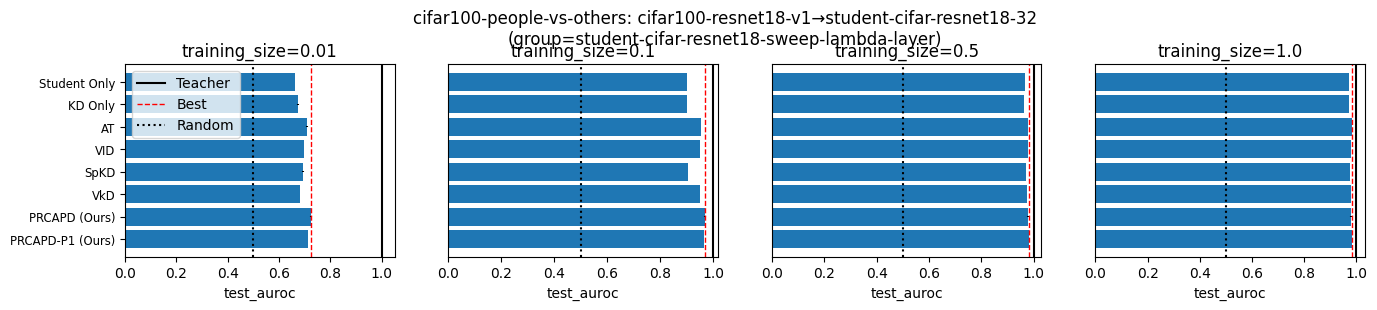

In [9]:
def _alias_policy(name):
    return {
        "student-only": "Student Only",
        "kd-only": "KD Only",
        "vid": "VID",
        "attention-transfer": "AT",
        "vkd": "VkD",
        "spkd": "SpKD",
        "basis-bn:pca": "PCA (Ours)",
        "basis-bn:gradpca": "GPCA (Ours)",
        "basis-bn:prcaposdef": "PRCAPD (Ours)",
        "basis-bn:prcaposdef-with-weight-p1": "PRCAPD-P1 (Ours)",
    }[name]

def viz(
    dataset_name,
    teacher, student, 
    arr_training_sizes=[
        0.01,
        0.1,  
        0.5,
        1.0
    ],
    arr_policies=[
        "student-only",
        "kd-only",
        "attention-transfer",
        "vid",
        "spkd",
        "vkd",
        "basis-bn:prcaposdef",
        "basis-bn:prcaposdef-with-weight-p1"
    ],
    experiment_group=EXPERIMENT_GROUP
):
    
    nrows = 1
    ncols = len(arr_training_sizes)
    
    plt.figure(figsize=(4*ncols, 2.5 * nrows))
    
    plt.suptitle(f"{dataset_name}: {teacher}→{student}\n(group={experiment_group})", y=1.1)
    
    metric_name = "test_auroc"
    
    xticks = np.arange(len(arr_policies))
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(1, ncols, tix +1)

        plt.title(f"training_size={training_size}")
        
        

#         return df
    
#         assert df.shape[0] == len(arr_policies)
        
        arr_means = np.zeros(len(arr_policies))
        arr_sems = np.zeros(len(arr_policies))
        
        for pix, policy in enumerate(arr_policies):

            _df = read_data_per_policy(
                teacher=teacher,
                student=student,
                dataset=dataset_name,
                policy_alias=policy,
                training_size=training_size,
                experiment_group=experiment_group
            )

            assert _df.shape[0] == 1
            assert (_df[metric_name]["count"].values == 3).all()
            value = _df[metric_name]["mean"].values[0]
            arr_means[pix] = value
            arr_sems[pix] = _df[metric_name]["sem"].values[0]
            
        
        teacher_value = _df.teacher_auroc["mean"].values[-1]
        
        
        plt.barh(
            xticks,
            arr_means,
            yerr=arr_sems
        )
    
        plt.axvline(teacher_value, ls="-", color="k", label="Teacher")
        
        plt.axvline(np.max(arr_means), color="r", lw=1, ls="--", label="Best")

        plt.axvline(0.5, ls=":", color="k", label="Random")
        
        plt.xlabel(metric_name)
        plt.gca().invert_yaxis()
        
        if tix == 0:
            
            plt.yticks(
                xticks, 
                list(map(lambda n: _alias_policy(n), arr_policies)),
                fontsize="small"
            )
            plt.legend()
        else:
            plt.yticks([])
        
        
        
viz(
    dataset_name="cifar100-people-vs-others",
    teacher="cifar100-resnet18-v1",
    student="student-cifar-resnet18-32"
)

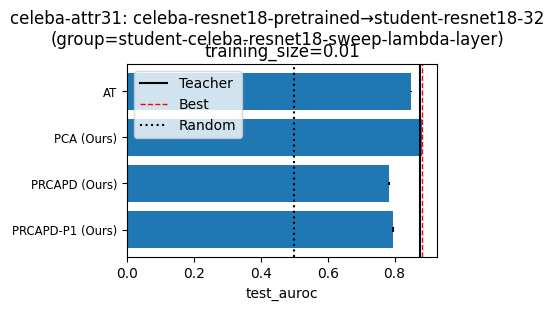

In [10]:
viz(
    dataset_name="celeba-attr31",
    teacher="celeba-resnet18-pretrained",
    student="student-resnet18-32",
    arr_training_sizes=[0.01],
    arr_policies=[
        "attention-transfer",
        "basis-bn:pca",
        "basis-bn:prcaposdef",
        "basis-bn:prcaposdef-with-weight-p1",
    ],
    experiment_group="student-celeba-resnet18-sweep-lambda-layer"
)